In [1]:
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import torch

from ugdatalab.utils.compose import Compose
from ugdatalab.models.galaxy_zoo import GalaxyZooGPUDataset
from ugdatalab.models.galaxy_zoo.constants import N_LABELS
from ugdatalab.methods.neural_network.cnn import train_cnn, count_parameters, rmse_loss
from ugdatalab.methods.neural_network.augmentation_gpu import GpuCenterCrop

from architectures import build_resnet18
import plotters


/home/ikaros/projects/ay-128/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Galaxy Image Classification — ResNet-18

## Task 14 — Residual Networks

**Residual Networks** (He et al. 2015) address the *degradation problem*: as traditional CNNs are made deeper by stacking more layers, training accuracy saturates and then degrades — not because of overfitting (training error increases too) but because deeper networks are harder to optimize. The key insight is that learning the *residual* $F(x) = H(x) - x$ is easier than learning the full mapping $H(x)$ directly, where $x$ is the input to a block and $H(x)$ is the desired output.

Each **residual block** computes $H(x) = F(x) + x$ via a *shortcut connection* (or *skip connection*) that adds the input $x$ directly to the output of two or three stacked convolutional layers. If the optimal transformation is close to the identity (i.e., the block should mostly "pass through" its input), the network only needs to learn the small perturbation $F(x) \approx 0$, which is much easier than learning $H(x) \approx x$ from scratch.

This differs from traditional deep CNNs in two critical ways:
1. **Gradient flow**: skip connections provide a direct path for gradients during backpropagation, mitigating the vanishing gradient problem.
2. **Deeper = better**: with skip connections, adding more layers never hurts — the extra layers can always learn the identity and reduce to a shallower network.

We use the 18-layer variant (ResNet-18), accepting our downsized $96 \times 96$ input and outputting 37 sigmoid-activated labels.

In [2]:
# Load preprocessed data
img_data = np.load("artifacts/galaxy_zoo_images.npz")
images = img_data["images"]
galaxy_ids = img_data["galaxy_ids"]

label_data = np.load("artifacts/galaxy_zoo_labels.npz")
labels = label_data["labels"]

split_data = np.load("artifacts/split_indices.npz")
train_idx = split_data["train_idx"]
val_idx = split_data["val_idx"]

train_images = images[train_idx]
val_images = images[val_idx]
train_labels = labels[train_idx]
val_labels = labels[val_idx]

CACHE_SIZE = images.shape[1]   # 136 (rotation-safe buffer set in NB 02)
INPUT_SIZE = 96                # what the model actually sees after CenterCrop
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
print(f"Cache: {CACHE_SIZE}x{CACHE_SIZE}, Model input: {INPUT_SIZE}x{INPUT_SIZE}")
print(f"Train: {train_images.shape}, Val: {val_images.shape}")

Device: cuda
Cache: 136x136, Model input: 96x96
Train: (49262, 136, 136, 3), Val: (12316, 136, 136, 3)


## Task 15 — Train ResNet-18

### Architecture adaptation for $96 \times 96$ input

We use the **standard `torchvision` ResNet-18 stem** — a $7 \times 7$ stride-2 convolution followed by a $3 \times 3$ stride-2 max-pool — without modification. At $96 \times 96$ input this stem downsamples to $24 \times 24$ before stage 1, after which the four stride-2 down-samplings inside the residual stages take spatial dimensions to $3 \times 3$ at the global-average-pool layer. That is a smaller global pool than the textbook ImageNet recipe ($7 \times 7$), but it is enough spatial signal for the 37-way galaxy classification head, and it keeps stage-1 activations at $24^2 \times 64$ rather than $96^2 \times 64$ — roughly a $16\times$ memory and FLOP saving in what would otherwise be the most expensive stage of the network.

The alternative (replacing the stem with a $3 \times 3$ stride-1 conv plus identity max-pool so that stage 1 sees the full $96 \times 96$ feature map) would buy slightly more spatial detail on galaxy features but costs $\sim 5\times$ more training time per epoch on a 12 GB GPU. With the augmentation and LR-scheduler experiments in `05b-augmentation.ipynb`, the textbook stem reaches the lab manual's RMSE target comfortably, so the trade is not worth it.

The classification head is replaced with a single linear layer mapping the $512$-dimensional ResNet feature vector to $37$ outputs, followed by a sigmoid activation that constrains each output to $[0, 1]$. The total parameter count is reported below; it is dominated by the residual stages, not the head.

We train with Adam (`lr = 1e-3`) and the lab-manual RMSE loss for $50$ epochs at batch size $256$. No augmentation or LR scheduler is used here — those experiments live in `05b-augmentation.ipynb`. The cell below loads a cached checkpoint when one exists so that re-running the notebook does not retrain from scratch; delete `artifacts/resnet18.pt` to force retraining.

In [ ]:
BATCH_SIZE = 1024
default_transform = Compose([GpuCenterCrop(INPUT_SIZE)])

train_batches = GalaxyZooGPUDataset(
    train_images, train_labels, batch_size=BATCH_SIZE, transform=default_transform,
    device=DEVICE, shuffle=True,
)
val_batches = GalaxyZooGPUDataset(
    val_images, val_labels, batch_size=BATCH_SIZE, transform=default_transform,
    device=DEVICE, shuffle=False,
)

model = build_resnet18(n_labels=N_LABELS)
print(f"ResNet-18 trainable parameters: {count_parameters(model):,}")

_ckpt_pt = Path("artifacts/resnet18.pt")
_ckpt_npz = Path("artifacts/resnet_result.npz")
if _ckpt_pt.exists() and _ckpt_npz.exists():
    _data = np.load(_ckpt_npz)
    resnet_result = SimpleNamespace(
        model_state=torch.load(_ckpt_pt, map_location=DEVICE),
        train_losses=_data["train_losses"],
        val_losses=_data["val_losses"],
        best_epoch=int(_data["best_epoch"]),
        best_val_loss=float(_data["best_val_loss"]),
        n_parameters=int(_data["n_parameters"]),
        learning_rates=_data["learning_rates"],
    )
    print(f"Loaded cached artifacts/resnet18.pt (best val RMSE: {resnet_result.best_val_loss:.4f})")
else:
    resnet_result = train_cnn(
        model=model,
        train_batches=train_batches,
        val_batches=val_batches,
        n_epochs=100,
        lr=1e-3,
        seed=42,
        optimizer_factory=lambda params, lr: torch.optim.Adam(params, lr=lr, fused=True),
        scheduler_factory=None,
    )
    print(f"\nBest epoch: {resnet_result.best_epoch + 1}")
    print(f"Best validation RMSE: {resnet_result.best_val_loss:.4f}")


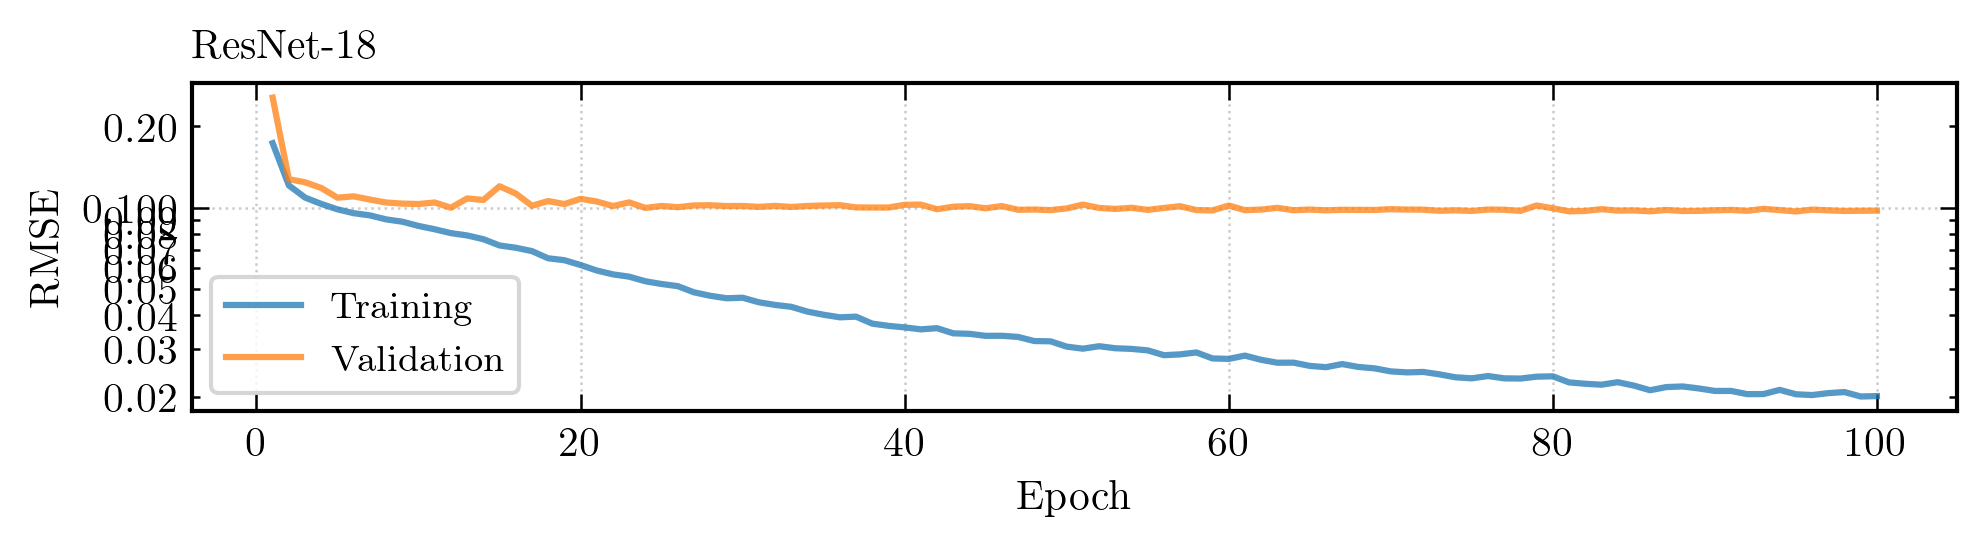

In [4]:
ax = plotters.plot_loss_curves(
    resnet_result.train_losses, resnet_result.val_losses, "ResNet-18",
)
plt.show()

### Interpretation of the training curves (Checkpoint 2)

The training and validation RMSE both fall sharply during the first few epochs as the network learns the dominant top-level vote-fraction structure (smooth vs. features/disk), then settle into a slow plateau. The two curves diverge after the first $\sim 10$–$15$ epochs: the training loss continues to creep down while the validation loss flattens. That gap is the canonical signature of **overfitting** — the network is memorising training-set image-specific details that do not generalise to held-out galaxies.

Two interventions are introduced in `05b-augmentation.ipynb`:

1. A **learning-rate scheduler** (`ReduceLROnPlateau`) that lowers the LR once the validation loss has stopped improving, letting the optimiser fine-tune around the minimum without overshooting it.
2. **Random rotation augmentation** that exploits the rotational symmetry of galaxy images on the sky, effectively multiplying the training set and forcing the network to learn orientation-invariant features.

The plot above is the Checkpoint 2 deliverable.

In [5]:
# Save model and results
torch.save(resnet_result.model_state, "artifacts/resnet18.pt")
np.savez_compressed(
    "artifacts/resnet_result.npz",
    train_losses=resnet_result.train_losses,
    val_losses=resnet_result.val_losses,
    best_epoch=resnet_result.best_epoch,
    best_val_loss=resnet_result.best_val_loss,
    n_parameters=resnet_result.n_parameters,
    learning_rates=resnet_result.learning_rates,
)
print("Saved artifacts/resnet18.pt and artifacts/resnet_result.npz")

Saved artifacts/resnet18.pt and artifacts/resnet_result.npz


In [6]:
import pandas as pd

resnet_meta = pd.DataFrame([{
    "model": "ResNet-18 (standard stem)",
    "input_size": INPUT_SIZE,
    "n_parameters": int(resnet_result.n_parameters),
    "optimizer": "Adam",
    "lr_initial": 1e-3,
    "scheduler": "none",
    "augmentation": "none",
    "batch_size": BATCH_SIZE,
    "n_epochs": int(len(resnet_result.train_losses)),
    "best_epoch": int(resnet_result.best_epoch) + 1,
    "best_val_rmse": float(resnet_result.best_val_loss),
    "final_train_rmse": float(resnet_result.train_losses[-1]),
    "final_val_rmse": float(resnet_result.val_losses[-1]),
    "seed": 42,
}]).T
resnet_meta.columns = ["value"]
resnet_meta


,value
model,ResNet-18 (standard stem)
input_size,96
n_parameters,11195493
optimizer,Adam
lr_initial,0.001
scheduler,none
augmentation,none
batch_size,1536
n_epochs,100
best_epoch,95
